In [1]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load the labels CSV
labels_df = pd.read_csv('cifar-10/trainLabels.csv')
print(labels_df.head(10))
print(f"\nTotal images: {len(labels_df)}")
print(f"\nUnique classes: {labels_df['label'].unique()}")

   id       label
0   1        frog
1   2       truck
2   3       truck
3   4        deer
4   5  automobile
5   6  automobile
6   7        bird
7   8       horse
8   9        ship
9  10         cat

Total images: 50000

Unique classes: <StringArray>
[      'frog',      'truck',       'deer', 'automobile',       'bird',
      'horse',       'ship',        'cat',        'dog',   'airplane']
Length: 10, dtype: str


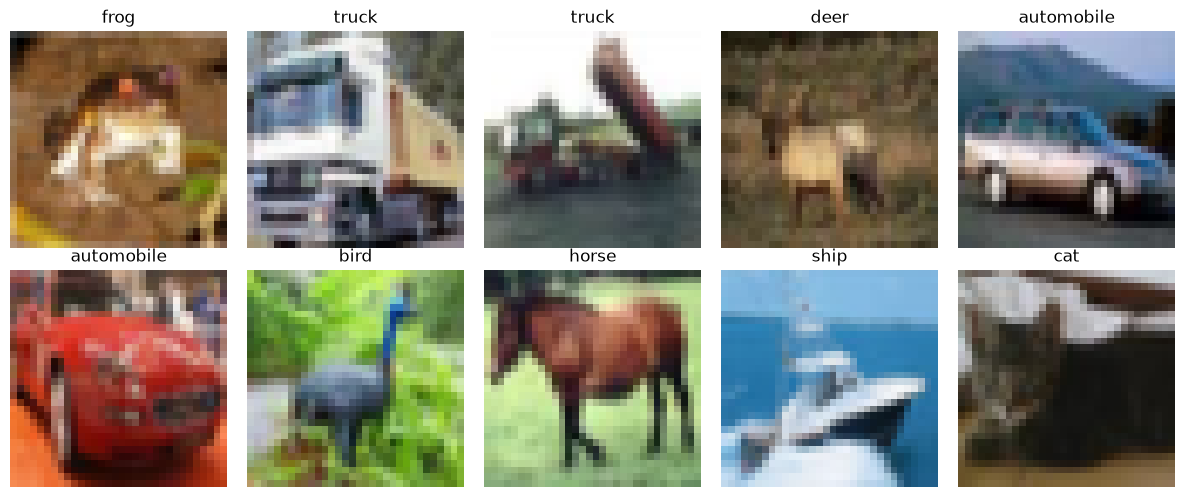

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img_id = labels_df.iloc[i, 0]          # get the numeric id
    label = labels_df.iloc[i, 1]           # get the label
    
    img_path = f'cifar-10/train/train/{img_id}.png'
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2 as transforms

class CIFARDataset(Dataset):
    # Dataset is a base class provided by PyTorch.
    # by inheriting from it, PyTorch knows how to work with our class
    # automatically — especially the DataLoader we'll create later.
    
    def __init__(self, labels_df, img_dir, augment=False):
        # __init__ is the constructor, called when you do CIFARDataset(...)
        # we're just storing the data we'll need later for lookups
        # augment=True for training data, False for validation data
        
        self.img_dir = img_dir
        
        # extract the image ids (first column) as a plain python list.
        # .values gives us a numpy array, .tolist() converts it to a list.
        self.img_ids = labels_df.iloc[:, 0].values.tolist()
        
        # extract the string labels (second column) the same way
        raw_labels = labels_df.iloc[:, 1].values.tolist()
        
        # the model needs integer labels, not strings like "dog" or "truck".
        # so we build a mapping from each unique label string to an integer.
        # sorted() ensures the mapping is consistent every time we run this.
        # example result: {"airplane":0, "automobile":1, "bird":2, ...}
        unique_labels = sorted(set(raw_labels))
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        
        # now convert every raw string label to its integer equivalent.
        # this is a list comprehension — equivalent to a foreach loop that
        # builds a new list, like: [transform(x) for x in collection]
        self.labels = [self.label_to_idx[label] for label in raw_labels]
        
        if augment:
            # training transform — includes random augmentations.
            # each of these is applied randomly every time an image is loaded,
            # so the model sees a different version of each image each epoch.
            self.transform = transforms.Compose([
                
                transforms.ToImage(),
                transforms.ToDtype(torch.float32, scale=True),
                
                # randomly flip the image horizontally with 50% probability.
                # a dog facing left is still a dog — this teaches the model that.
                transforms.RandomHorizontalFlip(p=0.5),
                
                # randomly crop the image — first pad it by 4 pixels on each
                # side, then crop back to 32x32. this teaches the model that
                # the subject doesn't always need to be perfectly centered.
                transforms.RandomCrop(32, padding=4),
                
                # randomly adjust brightness, contrast, saturation, and hue
                # by small amounts. teaches the model to recognize objects
                # regardless of lighting conditions or color variations.
                transforms.ColorJitter(
                    brightness=0.1,
                    contrast=0.1,
                    saturation=0.1,
                    hue=0.05
                ),
                
                transforms.Normalize(
                    mean=[0.4914, 0.4822, 0.4465],
                    std=[0.2470, 0.2435, 0.2616]
                )
            ])
        else:
            # validation transform — no augmentation, just the bare minimum
            # processing needed to feed the image to the model.
            self.transform = transforms.Compose([
                transforms.ToImage(),
                transforms.ToDtype(torch.float32, scale=True),
                transforms.Normalize(
                    mean=[0.4914, 0.4822, 0.4465],
                    std=[0.2470, 0.2435, 0.2616]
                )
            ])
    
    def __len__(self):
        # PyTorch calls this to know how many items are in the dataset.
        # it's used by the DataLoader to know when one full pass is complete.
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        # PyTorch calls this whenever it needs one specific item by index.
        # idx is just an integer — "give me item number 42"
        
        # build the full file path for this image
        img_path = os.path.join(self.img_dir, f"{self.img_ids[idx]}.png")
        
        # open the image as a PIL image (same as we did in the preview cell)
        image = Image.open(img_path)
        
        # apply our transform pipeline (ToTensor + Normalize)
        image = self.transform(image)
        
        # fetch the integer label for this image
        label = self.labels[idx]
        
        # return both as a tuple — PyTorch expects (data, label) pairs
        return image, label


# create an instance of our dataset, passing in the dataframe and image folder
dataset = CIFARDataset(labels_df, 'cifar-10/train/train')

print(f"Dataset size: {len(dataset)}")
print(f"Label mapping: {dataset.label_to_idx}")

Dataset size: 50000
Label mapping: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


Tensor shape: torch.Size([3, 32, 32])
Tensor value range: -1.99 to 2.09
Label index: 6


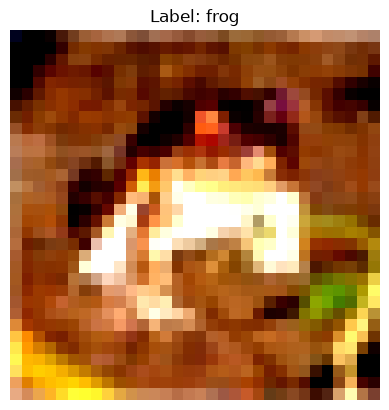

In [4]:
# fetch one sample from the dataset — this calls __getitem__(0) internally
image_tensor, label_idx = dataset[0]

print(f"Tensor shape: {image_tensor.shape}")
# shape will be [3, 32, 32] meaning 3 color channels, 32x32 pixels.
# note that pytorch orders dimensions as [channels, height, width],
# which is the opposite of what PIL and matplotlib expect.

print(f"Tensor value range: {image_tensor.min():.2f} to {image_tensor.max():.2f}")
# should be roughly -1.0 to 1.0 after normalization

print(f"Label index: {label_idx}")

# to display the tensor as an image we need to reverse the normalization
# and swap the dimension order back to [height, width, channels] for matplotlib.
# permute(1, 2, 0) rearranges from [channels, height, width] -> [height, width, channels]
img_to_show = image_tensor.permute(1, 2, 0)

# reverse the normalization: undo the -1 to 1 scaling back to 0.0-1.0
# clamp makes sure no values accidentally sneak outside that range
img_to_show = (img_to_show * 0.5 + 0.5).clamp(0, 1)

plt.imshow(img_to_show)
plt.title(f"Label: {list(dataset.label_to_idx.keys())[label_idx]}")
plt.axis('off')
plt.show()

In [5]:
from torch.utils.data import DataLoader

# load the pre-split CSVs instead of the original labels file
train_df = pd.read_csv('cifar-10/train_split.csv')
val_df = pd.read_csv('cifar-10/val_split.csv')

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")

# create separate datasets for training and validation.
# they point to the same image folder since the images aren't
# physically split — only the CSVs are different.
train_dataset = CIFARDataset(train_df, 'cifar-10/train/train', augment=True)
val_dataset = CIFARDataset(val_df, 'cifar-10/train/train', augment=False)

print(f"Label mapping: {train_dataset.label_to_idx}")

# training dataloader — shuffle is True so the model sees
# images in a different order each epoch
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# validation dataloader — shuffle is False since we're just
# measuring accuracy, order doesn't affect that.
# we can also use a larger batch size since we're not storing
# gradients during validation, which saves GPU memory.
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

Training images: 40000
Validation images: 10000
Label mapping: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Training batches per epoch: 1250
Validation batches per epoch: 157


Batch image tensor shape: torch.Size([32, 3, 32, 32])
Batch label tensor shape: torch.Size([32])


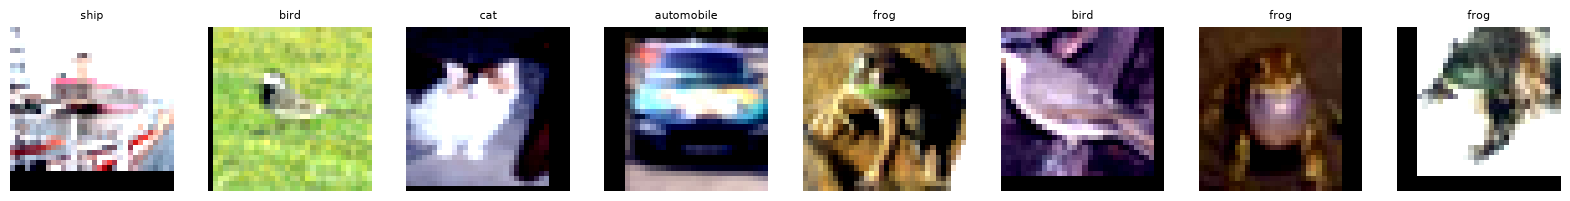

In [6]:
# grab one batch from the dataloader.
# next() fetches the first item from the iterator.
# iter() turns the dataloader into something we can call next() on.
images, labels = next(iter(train_loader))

print(f"Batch image tensor shape: {images.shape}")
# shape will be [32, 3, 32, 32] — batch_size, channels, height, width.
# this is the first time we've seen a 4-dimensional tensor —
# the batch dimension is just stacked on top of the per-image dimensions.

print(f"Batch label tensor shape: {labels.shape}")
# shape will be [32] — just a flat list of 32 integer labels

# display the first 8 images in the batch
fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i, ax in enumerate(axes):
    img = images[i]                         # grab one image tensor [3, 32, 32]
    img = img.permute(1, 2, 0)             # reorder to [32, 32, 3] for matplotlib
    img = (img * 0.5 + 0.5).clamp(0, 1)   # reverse normalization back to 0.0-1.0
    
    label_name = list(train_dataset.label_to_idx.keys())[labels[i]]
    
    ax.imshow(img)
    ax.set_title(label_name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn

class CIFARClassifier(nn.Module):
    
    def __init__(self, dropout=0.25):
        super().__init__()
        
        # --- FEATURE EXTRACTION LAYERS ---
        # these layers learn to recognize visual patterns in the image.
        # think of them as progressively learning simple -> complex features.
        # early layers might detect edges, later layers detect shapes/objects.
        
        # first convolutional layer.
        # takes the 3 input channels (R, G, B) and produces 32 "filtered" versions
        # of the image, each one highlighting different patterns it has learned.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        
        # second convolutional layer.
        # takes the 32 filtered images from conv1 and produces 64.
        # we're doubling the depth while the spatial size will be shrinking (see pool below).
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # third convolutional layer.
        # takes 64 and produces 128 — same pattern, more depth.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        # max pooling layer — we'll reuse this same layer multiple times in forward().
        # its job is to shrink the spatial size (height and width) of the image by half
        # after each convolutional layer, which reduces computation and helps the model
        # focus on the most prominent features rather than exact pixel positions.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ReLU activation function — also reused multiple times.
        # after each convolution, this introduces non-linearity by simply setting
        # any negative values to zero. without this, stacking layers would be
        # mathematically equivalent to just having one layer.
        self.relu = nn.ReLU()
        
        # --- CLASSIFICATION LAYERS ---
        # after feature extraction, we flatten the 3D output into a 1D list of numbers
        # and pass it through standard "dense" layers to produce the final prediction.
        
        # flatten converts [batch, channels, height, width] -> [batch, channels*height*width].
        # after 3 rounds of conv+pool on a 32x32 image:
        #   32x32 -> 16x16 (after pool 1)
        #   16x16 -> 8x8   (after pool 2)
        #   8x8   -> 4x4   (after pool 3)
        # so the flattened size is 128 channels * 4 * 4 = 2048
        self.flatten = nn.Flatten()
        
        # first dense layer — takes the 2048 flattened values down to 512.
        self.fc1 = nn.Linear(2048, 512)
        
        # output layer — takes 512 values down to 10, one per class.
        # the highest value among these 10 will be the model's predicted class.
        self.fc2 = nn.Linear(512, 10)
        
        # dropout — randomly disables neurons during training.
        # this forces the model to not rely too heavily on any single neuron,
        # which helps prevent overfitting (memorizing training data rather than
        # learning general patterns). dropout is automatically disabled during
        # evaluation/inference, we don't need to worry about that manually.
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x):
        # x starts as [batch_size, 3, 32, 32]
        
        x = self.relu(self.conv1(x))  # -> [batch_size, 32, 32, 32]
        x = self.pool(x)              # -> [batch_size, 32, 16, 16]
        
        x = self.relu(self.conv2(x))  # -> [batch_size, 64, 16, 16]
        x = self.pool(x)              # -> [batch_size, 64, 8, 8]
        
        x = self.relu(self.conv3(x))  # -> [batch_size, 128, 8, 8]
        x = self.pool(x)              # -> [batch_size, 128, 4, 4]
        
        x = self.flatten(x)           # -> [batch_size, 2048]
        x = self.dropout(x)           # randomly zero out 25% of values
        
        x = self.relu(self.fc1(x))    # -> [batch_size, 512]
        x = self.dropout(x)           # dropout again before final layer
        
        x = self.fc2(x)               # -> [batch_size, 10]
        return x


## instantiate the model and move it to the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# model = CIFARClassifier().to(device)

# # print a summary of the model's layers and parameter counts
# print(model)

Using device: cuda
CIFARClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [ ]:
import torch.optim as optim

# how many times we'll loop through the entire dataset.
# one full pass through all the data is called an "epoch".
# more epochs = more learning, but also more time and risk of overfitting.
# NUM_EPOCHS = 60

# CrossEntropyLoss measures how wrong the model's predictions are.
# it expects raw scores from the model (not probabilities) and the
# correct class index as an integer — which is exactly what we're providing.
criterion = nn.CrossEntropyLoss()

# AdamW optimizer — this is what actually adjusts the weights after each batch.
# model.parameters() tells it which values it's allowed to adjust (all of them).
# lr is the learning rate — how big a step to take with each adjustment.
# 0.001 is a safe default starting point for AdamW.
#optimizer = optim.AdamW(model.parameters(), lr=0.001)

# CosineAnnealingLR smoothly reduces the learning rate following a
# cosine curve over the entire training run, rather than making
# sudden sharp drops every 10 epochs. this tends to produce better
# final results as the learning rate decays more gracefully.
# T_max is the number of epochs over which to complete the annealing.
#scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

#print(f"Training for {NUM_EPOCHS} epochs")
print(f"Loss function: {criterion}")
#print(f"Optimizer: {optimizer}")

Training for 60 epochs
Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)


In [9]:
import optuna
from optuna.samplers import TPESampler

# TPE (Tree-structured Parzen Estimator) is the Bayesian sampler —
# this is what makes Optuna smarter than random search.
# it builds a probabilistic model of which parameters work well
# and uses it to choose the next trial's parameters intelligently.

# how many epochs to train per trial. we use fewer epochs than our
# full training run to keep each trial fast — we're looking for
# promising directions, not fully converged models.
TRIAL_EPOCHS = 20

def objective(trial):
    # this function is called once per trial by Optuna.
    # trial.suggest_* methods let Optuna choose the value for each
    # parameter, guided by what it has learned from previous trials.
    
    # suggest a learning rate on a log scale — this means Optuna
    # explores values like 0.0001, 0.001, 0.01 proportionally rather
    # than linearly. log scale is standard for learning rates since
    # the difference between 0.0001 and 0.001 matters as much as
    # the difference between 0.001 and 0.01.
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    # suggest a batch size from a fixed set of choices
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    # suggest a dropout rate as a continuous value between 0.1 and 0.5
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    
    # suggest which optimizer to use
    optimizer_name = trial.suggest_categorical('optimizer', ['AdamW', 'SGD'])
    
    # suggest which scheduler to use
    scheduler_name = trial.suggest_categorical('scheduler', ['CosineAnnealingLR', 'StepLR'])
    
    # build fresh datasets and dataloaders using the suggested batch size.
    # we have to rebuild the dataloader each trial since batch size changed.
    trial_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    trial_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size * 2,  # validation can use double the batch size
        shuffle=False,
        num_workers=2
    )
    
    # build a fresh model with the suggested dropout rate.
    # we need to modify CIFARClassifier to accept dropout as a parameter.
    trial_model = CIFARClassifier(dropout=dropout).to(device)
    
    # build the suggested optimizer
    if optimizer_name == 'AdamW':
        trial_optimizer = optim.AdamW(trial_model.parameters(), lr=lr)
    else:
        # SGD works better with a higher learning rate and momentum.
        # momentum helps SGD move more consistently in the right direction
        # by accumulating a fraction of the previous update.
        trial_optimizer = optim.SGD(
            trial_model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=1e-4
        )
    
    # build the suggested scheduler
    if scheduler_name == 'CosineAnnealingLR':
        trial_scheduler = optim.lr_scheduler.CosineAnnealingLR(
            trial_optimizer, T_max=TRIAL_EPOCHS
        )
    else:
        trial_scheduler = optim.lr_scheduler.StepLR(
            trial_optimizer, step_size=7, gamma=0.1
        )
    
    trial_criterion = nn.CrossEntropyLoss()
    
    # run the training loop for TRIAL_EPOCHS epochs
    for epoch in range(TRIAL_EPOCHS):
        
        # training phase
        trial_model.train()
        for images, labels in trial_train_loader:
            images = images.to(device)
            labels = labels.to(device)
            trial_optimizer.zero_grad()
            outputs = trial_model(images)
            loss = trial_criterion(outputs, labels)
            loss.backward()
            trial_optimizer.step()
        
        trial_scheduler.step()
        
        # validation phase
        trial_model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in trial_val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = trial_model(images)
                _, predicted = torch.max(outputs, dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = val_correct / val_total
        
        # report this epoch's result to Optuna.
        # Optuna uses these intermediate values to prune bad trials early —
        # if a trial is clearly underperforming after a few epochs, Optuna
        # can stop it and move on to the next one, saving significant time.
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    # return the final validation accuracy as the metric to optimize.
    # Optuna will try to maximize this value across all trials.
    return val_acc


# create the study — this is Optuna's container for the entire
# optimization run. it tracks all trials and their results.
# direction='maximize' tells Optuna we want the highest val accuracy.
# the TPESampler is what implements the Bayesian optimization strategy.
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(),
    # MedianPruner stops a trial early if its intermediate results are
    # below the median of previous trials at the same epoch.
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

print("Starting hyperparameter search...")
print(f"Running {20} trials of {TRIAL_EPOCHS} epochs each.")
print("This will take approximately 3-5 hours.\n")

[I 2026-06-28 00:21:33,130] A new study created in memory with name: no-name-706c08fa-fee5-4c65-9dc2-e58da4db02bd


Starting hyperparameter search...
Running 20 trials of 20 epochs each.
This will take approximately 3-5 hours.



In [10]:
# optimize() starts the trial loop. n_trials is how many trials to run.
# each trial calls our objective() function once with different parameters.
study.optimize(objective, n_trials=20)

# print the results
print("\n=== HYPERPARAMETER SEARCH COMPLETE ===")
print(f"Best validation accuracy: {study.best_value * 100:.2f}%")
print(f"Best parameters found:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

[I 2026-06-28 00:25:18,327] Trial 0 finished with value: 0.7814 and parameters: {'lr': 0.0004809192198147611, 'batch_size': 32, 'dropout': 0.3795801981627579, 'optimizer': 'AdamW', 'scheduler': 'StepLR'}. Best is trial 0 with value: 0.7814.
[I 2026-06-28 00:28:54,716] Trial 1 finished with value: 0.4815 and parameters: {'lr': 0.00101882974125155, 'batch_size': 128, 'dropout': 0.33403925592617534, 'optimizer': 'SGD', 'scheduler': 'CosineAnnealingLR'}. Best is trial 0 with value: 0.7814.
[I 2026-06-28 00:32:34,302] Trial 2 finished with value: 0.8055 and parameters: {'lr': 0.007286809343188923, 'batch_size': 64, 'dropout': 0.16761750952019294, 'optimizer': 'SGD', 'scheduler': 'CosineAnnealingLR'}. Best is trial 2 with value: 0.8055.
[I 2026-06-28 00:36:14,878] Trial 3 finished with value: 0.3144 and parameters: {'lr': 0.0001405759555140999, 'batch_size': 64, 'dropout': 0.26133966602313985, 'optimizer': 'SGD', 'scheduler': 'CosineAnnealingLR'}. Best is trial 2 with value: 0.8055.
[I 2026-


=== HYPERPARAMETER SEARCH COMPLETE ===
Best validation accuracy: 82.74%
Best parameters found:
  lr: 0.0066244400307505225
  batch_size: 32
  dropout: 0.17851878421865774
  optimizer: SGD
  scheduler: CosineAnnealingLR


In [13]:
# reinitialize everything from scratch using the best parameters found by Optuna
best_params = study.best_params
print(f"Training with best parameters: {best_params}")

# fresh model with the tuned dropout value
model = CIFARClassifier(dropout=best_params['dropout']).to(device)

# rebuild dataloaders with the tuned batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=best_params['batch_size'],
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=best_params['batch_size'] * 2,
    shuffle=False,
    num_workers=2
)

# SGD with momentum — momentum is important for SGD and should
# always be set to 0.9 as a standard practice
optimizer = optim.SGD(
    model.parameters(),
    lr=best_params['lr'],
    momentum=0.9,
    weight_decay=1e-4
)

# cosine annealing over the full 60 epochs
NUM_EPOCHS = 60
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training batches per epoch: {len(train_loader)}")

Training with best parameters: {'lr': 0.0066244400307505225, 'batch_size': 32, 'dropout': 0.17851878421865774, 'optimizer': 'SGD', 'scheduler': 'CosineAnnealingLR'}
Model parameters: 1,147,466
Training batches per epoch: 1250


In [14]:
# put the model in training mode. this enables behaviors that should
# only happen during training, like dropout randomly disabling neurons.
# the model has two modes: model.train() and model.eval().
model.train()

for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    
    # track the total loss across all batches in this epoch
    running_loss = 0.0
    # track how many predictions were correct
    correct = 0
    # track how many images we've processed total
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        
        # move the images and labels to the GPU.
        # they come off the dataloader as CPU tensors, so we need to
        # explicitly move them to the same device as the model.
        images = images.to(device)
        labels = labels.to(device)
        
        # zero out the gradients from the previous batch.
        # gradients accumulate by default in PyTorch — if we don't
        # clear them, they'd stack up across batches and corrupt the updates.
        optimizer.zero_grad()
        
        # forward pass — feed the images through the model.
        # this calls our forward() method and returns raw scores for each class.
        # shape: [batch_size, 10] — one score per class per image.
        outputs = model(images)
        
        # calculate the loss — how wrong were our predictions?
        # criterion compares our raw scores against the correct labels.
        loss = criterion(outputs, labels)
        
        # backward pass — calculate how much each weight contributed to the loss.
        # this is backpropagation. PyTorch handles all the math automatically.
        loss.backward()
        
        # update the weights based on the gradients calculated above.
        # this is the actual "learning" step.
        optimizer.step()
        
        # accumulate the loss for reporting.
        # .item() converts a single-value tensor to a plain python float.
        running_loss += loss.item()
        
        # calculate accuracy for this batch.
        # outputs contains raw scores — the highest score is the prediction.
        # torch.max returns both the highest value and its index.
        # we only want the index (which class), so we use _ for the value.
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # print progress every 200 batches so we can see it's working
        if (batch_idx + 1) % 200 == 0:
            print(
                f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {running_loss / (batch_idx + 1):.4f} "
                f"Accuracy: {100 * correct / total:.2f}%"
            )
            
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # --- VALIDATION PHASE ---
    # torch.no_grad() tells PyTorch not to calculate or store gradients
    # during this phase. we're not learning here, just measuring, so
    # there's no need — and skipping it saves significant GPU memory.
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    
    # step the scheduler at the end of each epoch.
    # this is what actually reduces the learning rate every 10 epochs.
    scheduler.step()
    
    # print both training and validation results for this epoch.
    # the gap between train_acc and val_acc is your overfitting indicator —
    # a large gap means the model is memorizing rather than generalizing.
    print(
        f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] Complete | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ---\n"
    )

Epoch [1/60] Batch [200/1250] Loss: 2.1634 Accuracy: 19.92%
Epoch [1/60] Batch [400/1250] Loss: 2.0340 Accuracy: 24.77%
Epoch [1/60] Batch [600/1250] Loss: 1.9366 Accuracy: 28.34%
Epoch [1/60] Batch [800/1250] Loss: 1.8623 Accuracy: 31.19%
Epoch [1/60] Batch [1000/1250] Loss: 1.8048 Accuracy: 33.37%
Epoch [1/60] Batch [1200/1250] Loss: 1.7586 Accuracy: 35.12%

--- Epoch [1/60] Complete | Train Loss: 1.7467 | Train Acc: 35.54% | Val Loss: 1.3579 | Val Acc: 50.46% ---

Epoch [2/60] Batch [200/1250] Loss: 1.4839 Accuracy: 45.47%
Epoch [2/60] Batch [400/1250] Loss: 1.4392 Accuracy: 47.24%
Epoch [2/60] Batch [600/1250] Loss: 1.4126 Accuracy: 48.62%
Epoch [2/60] Batch [800/1250] Loss: 1.3941 Accuracy: 49.30%
Epoch [2/60] Batch [1000/1250] Loss: 1.3725 Accuracy: 50.21%
Epoch [2/60] Batch [1200/1250] Loss: 1.3512 Accuracy: 50.98%

--- Epoch [2/60] Complete | Train Loss: 1.3469 | Train Acc: 51.15% | Val Loss: 1.0910 | Val Acc: 61.85% ---

Epoch [3/60] Batch [200/1250] Loss: 1.2085 Accuracy: 56.

In [15]:
torch.save({
    # the model's learned weights — the "knowledge"
    'model_state_dict': model.state_dict(),
    
    # the optimizer state — saved in case we want to resume training
    # later rather than starting from scratch
    'optimizer_state_dict': optimizer.state_dict(),
    
    # metadata about this training run, useful for keeping track
    # of what produced this version of the model
    'epoch': NUM_EPOCHS,
    'train_acc': 86.22,
    'val_acc': 85.18,
    'notes': 'mild augmentation, cosine annealing, 60 epochs'
}, 'cifar_model_86_21.pth')

print("Model saved.")

Model saved.
